In [1]:
# Cell 1：Imports + 基本設定
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.manifold import TSNE

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device =", device)

PROJ = Path(r"D:/中興大學/碩一上/仁愛醫院/仁愛醫院調整8總整理").resolve()
DATA_ROOT = PROJ / "stage_cls_dataset"   # stage_1..stage_4


device = cuda


In [2]:
# Cell 2：DataLoader（4-class，並保留路徑/GT label）
val_tf = T.Compose([
    T.Resize((384, 384)),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3)
])

ds4 = ImageFolder(DATA_ROOT, transform=val_tf)
print("class_to_idx:", ds4.class_to_idx)  # 期待 stage_1..stage_4 -> 0..3

val_loader_4 = DataLoader(ds4, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)


class_to_idx: {'stage_1': 0, 'stage_2': 1, 'stage_3': 2, 'stage_4': 3}


In [3]:
# ============================================================
# MUST HAVE: create_model() (same as training)
# Put this cell BEFORE you create/load m1/m2/m3
# ============================================================

import torch
import torch.nn as nn
import torchvision.models as models

def create_model(model_name: str, num_classes: int = 2):
    """
    Build a torchvision model backbone with pretrained weights,
    and replace the final classification layer to num_classes.

    model_name options (match your training notebooks):
      efficientnet_b0, efficientnet_b1, resnet50,
      convnext_tiny, convnext_small, convnext_base,
      vit_b_16, densenet121, densenet169
    """
    model_name = model_name.lower()

    if model_name == "efficientnet_b0":
        weights = models.EfficientNet_B0_Weights.DEFAULT
        model = models.efficientnet_b0(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    elif model_name == "efficientnet_b1":
        weights = models.EfficientNet_B1_Weights.DEFAULT
        model = models.efficientnet_b1(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    elif model_name == "resnet50":
        weights = models.ResNet50_Weights.DEFAULT
        model = models.resnet50(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    elif model_name == "convnext_tiny":
        weights = models.ConvNeXt_Tiny_Weights.DEFAULT
        model = models.convnext_tiny(weights=weights)
        in_features = model.classifier[2].in_features
        model.classifier[2] = nn.Linear(in_features, num_classes)

    elif model_name == "convnext_small":
        weights = models.ConvNeXt_Small_Weights.DEFAULT
        model = models.convnext_small(weights=weights)
        in_features = model.classifier[2].in_features
        model.classifier[2] = nn.Linear(in_features, num_classes)

    elif model_name == "convnext_base":
        weights = models.ConvNeXt_Base_Weights.DEFAULT
        model = models.convnext_base(weights=weights)
        in_features = model.classifier[2].in_features
        model.classifier[2] = nn.Linear(in_features, num_classes)

    elif model_name == "vit_b_16":
        weights = models.ViT_B_16_Weights.DEFAULT
        model = models.vit_b_16(weights=weights)
        in_features = model.heads.head.in_features
        model.heads.head = nn.Linear(in_features, num_classes)

    elif model_name == "densenet121":
        weights = models.DenseNet121_Weights.DEFAULT
        model = models.densenet121(weights=weights)
        in_features = model.classifier.in_features
        model.classifier = nn.Linear(in_features, num_classes)

    elif model_name == "densenet169":
        weights = models.DenseNet169_Weights.DEFAULT
        model = models.densenet169(weights=weights)
        in_features = model.classifier.in_features
        model.classifier = nn.Linear(in_features, num_classes)

    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    return model


In [4]:
# Cell 3：建模 + 載入權重（m1/m2/m3）
# --- ckpt paths (照你貼的) ---
M1_CKPT = PROJ / "outputs_bin(1,2,3),(4)" / "_best_model" / "best_densenet121.pth"
M2_CKPT = PROJ / "outputs_bin(1),(2,3,4)" / "_best_model" / "best_efficientnet_b0.pth"
M3_CKPT = PROJ / "outputs_bin(2),(3)" / "_best_model" / "best_densenet121.pth"

m1 = create_model("densenet121", num_classes=2).to(device)
m2 = create_model("efficientnet_b0", num_classes=2).to(device)
m3 = create_model("densenet121", num_classes=2).to(device)

# load weights
m1.load_state_dict(torch.load(M1_CKPT, map_location=device))
m2.load_state_dict(torch.load(M2_CKPT, map_location=device))
m3.load_state_dict(torch.load(M3_CKPT, map_location=device))

m1.eval(); m2.eval(); m3.eval()
print("Loaded m1/m2/m3 ckpts.")


Loaded m1/m2/m3 ckpts.


In [5]:
# Cell 4：抽 embedding 的通用函式（支援 DenseNet / ResNet / EfficientNet / ConvNeXt）
@torch.no_grad()
def forward_features(model, x):
    # ViT torchvision 特例（你目前沒用 ViT 可忽略，但保留也不會壞）
    if hasattr(model, "encoder") and hasattr(model, "heads"):
        x = model._process_input(x)
        n = x.shape[0]
        cls = model.class_token.expand(n, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = model.encoder(x)
        return x[:, 0]  # CLS token

    # DenseNet / EfficientNet / ConvNeXt 常見都有 .features
    if hasattr(model, "features"):
        x = model.features(x)
        if x.dim() == 4:
            x = torch.nn.functional.adaptive_avg_pool2d(x, 1).flatten(1)
        else:
            x = x.flatten(1)
        return x

    # ResNet 類
    if hasattr(model, "avgpool"):
        x = model.conv1(x); x = model.bn1(x); x = model.relu(x); x = model.maxpool(x)
        x = model.layer1(x); x = model.layer2(x); x = model.layer3(x); x = model.layer4(x)
        x = model.avgpool(x)
        x = torch.flatten(x, 1)
        return x

    raise RuntimeError("Unsupported model type for feature extraction.")

@torch.no_grad()
def extract_embeddings_filtered(model, loader, device, keep_y4=None, max_batches=None):
    """
    keep_y4: None 或 set/list，例如 {0,1,2} 只保留 stage1/2/3
    回傳 feats(N,D), y4(N,)
    """
    model.eval()
    feats_all, y4_all = [], []

    for bi, (imgs, y4) in enumerate(loader):
        if keep_y4 is not None:
            mask = torch.zeros_like(y4, dtype=torch.bool)
            for k in keep_y4:
                mask |= (y4 == k)
            if mask.sum().item() == 0:
                continue
            imgs = imgs[mask]
            y4 = y4[mask]

        imgs = imgs.to(device, non_blocking=True)
        feats = forward_features(model, imgs).detach().cpu().numpy()
        feats_all.append(feats)
        y4_all.append(y4.numpy())

        if max_batches is not None and (bi + 1) >= max_batches:
            break

    feats_all = np.concatenate(feats_all, axis=0) if len(feats_all) else np.zeros((0, 1))
    y4_all = np.concatenate(y4_all, axis=0) if len(y4_all) else np.zeros((0,), dtype=int)
    return feats_all, y4_all


In [6]:
# Cell 5：t-SNE 繪圖函式（可調 perplexity / 點大小）想把圖存檔
def plot_tsne_and_save(feats, labels, title, label_names, save_path, perplexity=30, seed=42, point_size=10):
    tsne = TSNE(
        n_components=2,
        perplexity=min(perplexity, max(5, (len(feats)-1)//3)),
        init="pca",
        learning_rate="auto",
        random_state=seed
    )
    z = tsne.fit_transform(feats)

    plt.figure(figsize=(7, 6))
    for c in np.unique(labels):
        m = labels == c
        plt.scatter(z[m, 0], z[m, 1], s=point_size, alpha=0.75, label=label_names[int(c)])
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print("saved:", save_path)



In [7]:
from pathlib import Path

OUT_GRAPH_DIR = PROJ / "combination_graphs"
OUT_GRAPH_DIR.mkdir(parents=True, exist_ok=True)

print("t-SNE graphs will be saved to:", OUT_GRAPH_DIR)


t-SNE graphs will be saved to: D:\中興大學\碩一上\仁愛醫院\仁愛醫院調整8總整理\combination_graphs


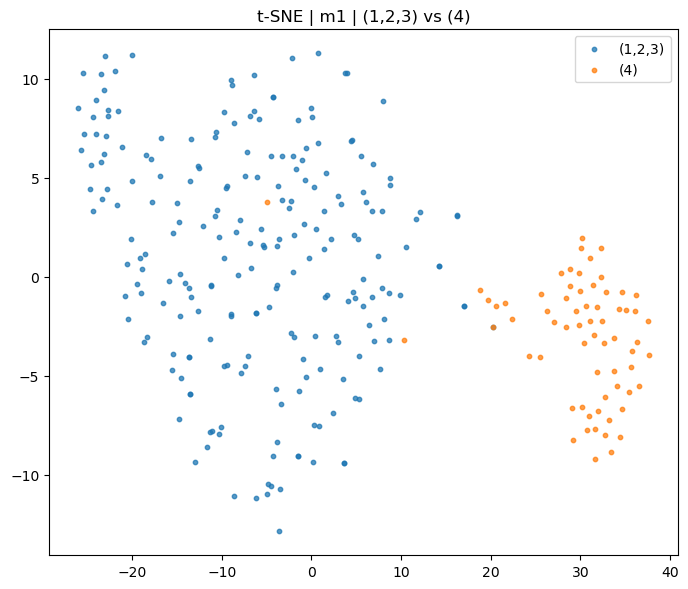

saved: D:\中興大學\碩一上\仁愛醫院\仁愛醫院調整8總整理\combination_graphs\tsne_m1_(123)_vs_(4).png


In [8]:
feats_m1, y4_m1 = extract_embeddings_filtered(m1, val_loader_4, device=device, keep_y4={0,1,2,3})

# m1 target: 0:(1,2,3) vs 1:(4)
y_m1 = (y4_m1 == 3).astype(int)

plot_tsne_and_save(
    feats_m1,
    y_m1,
    title="t-SNE | m1 | (1,2,3) vs (4)",
    label_names=["(1,2,3)", "(4)"],
    save_path=OUT_GRAPH_DIR / "tsne_m1_(123)_vs_(4).png",
    perplexity=30
)


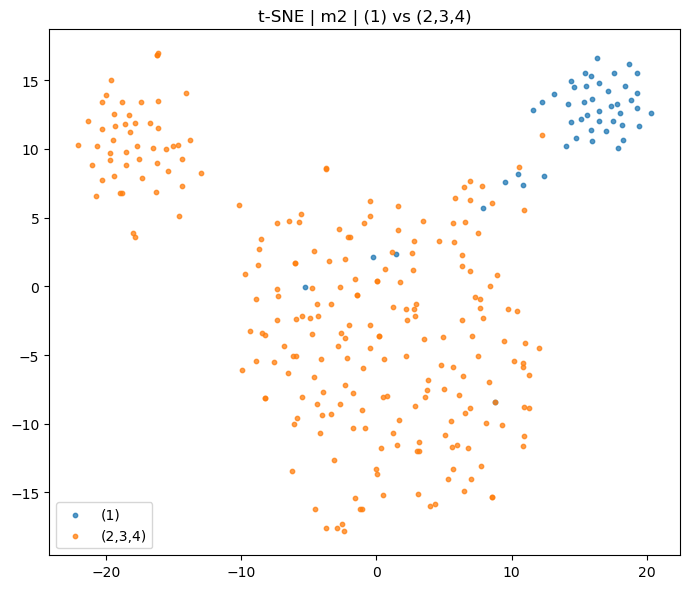

saved: D:\中興大學\碩一上\仁愛醫院\仁愛醫院調整8總整理\combination_graphs\tsne_m2_(1)_vs_(234).png


In [9]:
feats_m2, y4_m2 = extract_embeddings_filtered(m2, val_loader_4, device=device, keep_y4={0,1,2,3})

# m2 target: 0:(1) vs 1:(2,3,4)
y_m2 = (y4_m2 != 0).astype(int)

plot_tsne_and_save(
    feats_m2,
    y_m2,
    title="t-SNE | m2 | (1) vs (2,3,4)",
    label_names=["(1)", "(2,3,4)"],
    save_path=OUT_GRAPH_DIR / "tsne_m2_(1)_vs_(234).png",
    perplexity=30
)


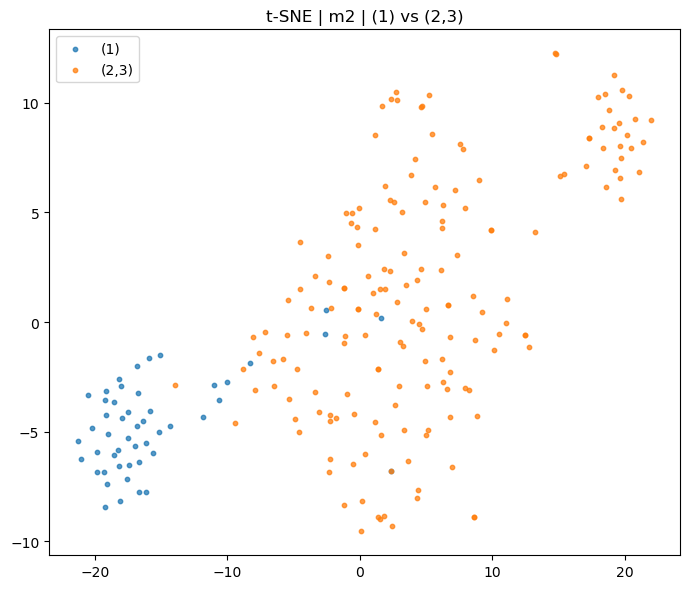

saved: D:\中興大學\碩一上\仁愛醫院\仁愛醫院調整8總整理\combination_graphs\tsne_m2_(1)_vs_(23).png


In [10]:
feats_m2, y4_m2 = extract_embeddings_filtered(m2, val_loader_4, device=device, keep_y4={0,1,2})  # 只留1/2/3

y_m2 = (y4_m2 != 0).astype(int)  # 0:(1) 1:(2,3)

plot_tsne_and_save(
    feats_m2,
    y_m2,
    title="t-SNE | m2 | (1) vs (2,3)",
    label_names=["(1)", "(2,3)"],
    save_path=OUT_GRAPH_DIR / "tsne_m2_(1)_vs_(23).png",
    perplexity=30
)

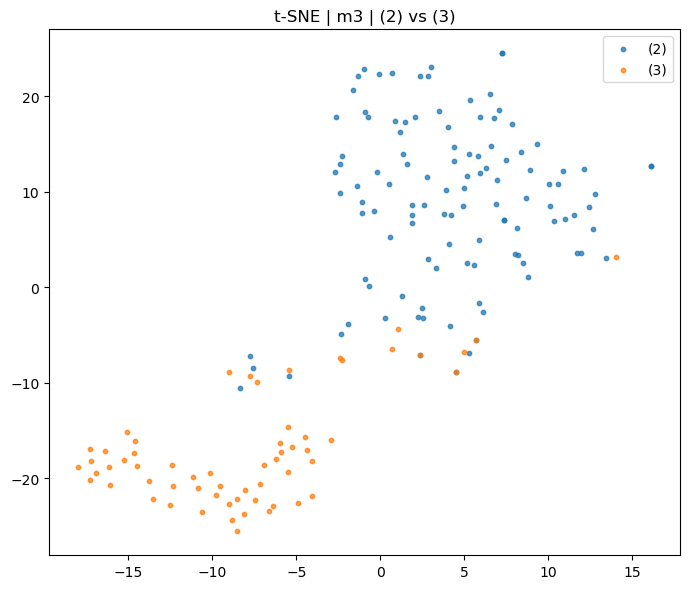

saved: D:\中興大學\碩一上\仁愛醫院\仁愛醫院調整8總整理\combination_graphs\tsne_m3_(2)_vs_(3).png


In [11]:
feats_m3, y4_m3 = extract_embeddings_filtered(m3, val_loader_4, device=device, keep_y4={1,2})

# y4: 1=stage2, 2=stage3 → 轉成 0/1
y_m3 = (y4_m3 == 2).astype(int)

plot_tsne_and_save(
    feats_m3,
    y_m3,
    title="t-SNE | m3 | (2) vs (3)",
    label_names=["(2)", "(3)"],
    save_path=OUT_GRAPH_DIR / "tsne_m3_(2)_vs_(3).png",
    perplexity=20
)
